In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches = pd.read_csv('matches.csv')
deleveries = pd.read_csv('deliveries.csv')

# Understanding Data

## How big is the data?

In [3]:
matches.shape

(1095, 20)

In [4]:
deleveries.shape

(260920, 17)

## How does the data looks like?

In [5]:
matches.sample(7)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
948,1312199,2022,Ahmedabad,2022-05-27,Qualifier 2,JC Buttler,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,7.0,158.0,20.0,N,NaN,CB Gaffaney,Nitin Menon
316,548376,2012,Hyderabad,2012-05-20,League,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Deccan Chargers,runs,9.0,133.0,20.0,N,NaN,S Ravi,SJA Taufel
95,392220,2009,Kimberley,2009-05-11,League,DR Smith,De Beers Diamond Oval,Deccan Chargers,Rajasthan Royals,Deccan Chargers,bat,Deccan Chargers,runs,53.0,167.0,20.0,N,NaN,GAV Baxter,HDPK Dharmasena
951,1359476,2023,Chandigarh,2023-04-01,League,Arshdeep Singh,"Punjab Cricket Association IS Bindra Stadium, ...",Punjab Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,Punjab Kings,runs,7.0,154.0,16.0,N,D/L,BNJ Oxenford,YC Barde
865,1254110,2021,Dubai,2021-10-04,League,AR Patel,Dubai International Cricket Stadium,Chennai Super Kings,Delhi Capitals,Delhi Capitals,field,Delhi Capitals,wickets,3.0,137.0,20.0,N,NaN,AK Chaudhary,Nitin Menon
207,501231,2011,Jaipur,2011-04-29,League,J Botha,Sawai Mansingh Stadium,Rajasthan Royals,Mumbai Indians,Rajasthan Royals,field,Rajasthan Royals,wickets,7.0,95.0,20.0,N,NaN,Asad Rauf,SK Tarapore
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe


In [6]:
deleveries.sample(7)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
247686,1422134,2,Delhi Capitals,Kolkata Knight Riders,6,6,RR Pant,AD Russell,T Stubbs,0,0,0,NaN,0,NaN,NaN,NaN
231316,1359496,2,Mumbai Indians,Kolkata Knight Riders,17,2,N Wadhera,LH Ferguson,TH David,0,0,0,NaN,1,N Wadhera,caught,Rahmanullah Gurbaz
95692,729287,2,Royal Challengers Bangalore,Mumbai Indians,8,6,AB de Villiers,PP Ojha,PA Patel,1,0,1,NaN,0,NaN,NaN,NaN
171509,1178403,2,Royal Challengers Bangalore,Kings XI Punjab,14,1,AB de Villiers,M Ashwin,V Kohli,1,0,1,NaN,0,NaN,NaN,NaN
17029,392198,2,Rajasthan Royals,Delhi Daredevils,2,5,GC Smith,DP Nannes,RJ Quiney,0,0,0,NaN,0,NaN,NaN,NaN
152219,1136568,2,Royal Challengers Bangalore,Kings XI Punjab,8,3,AB de Villiers,AR Patel,Q de Kock,0,0,0,NaN,0,NaN,NaN,NaN
131251,980973,2,Mumbai Indians,Sunrisers Hyderabad,12,4,Harbhajan Singh,MC Henriques,MJ McClenaghan,1,0,1,NaN,0,NaN,NaN,NaN


## What is the data type of features (columns)

In [7]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [8]:
deleveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

## Are there any missing values ? 

In [9]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

we can see the column city , result_margin , target_runs, target_overs , method has null values

In [10]:
deleveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

here also extras_type ,player_dismissed ,dismissal_kind ,fielder are missing

## how does the data look like mathematically ??

In [11]:
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [12]:
deleveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


## Are there any duplicated values ??

In [13]:
matches.duplicated().sum()

0

In [14]:
deleveries.duplicated().sum()

0

## how is the correlation between columns ?? imp

In [15]:
numeric_matches = matches.select_dtypes(include='number')
correlation = numeric_matches.corr()['result_margin']
correlation

id              -0.006853
result_margin    1.000000
target_runs      0.395120
target_overs     0.030970
Name: result_margin, dtype: float64

In [16]:
numeric_deleveries = deleveries.select_dtypes(include='number')
corr = numeric_deleveries.corr()['batsman_runs']
corr

match_id        0.036742
inning         -0.005690
over            0.080040
ball            0.004391
batsman_runs    1.000000
extra_runs     -0.142079
total_runs      0.977934
is_wicket      -0.171751
Name: batsman_runs, dtype: float64

In [17]:
# lets do some univariate anlysis

## Univariate Analysis

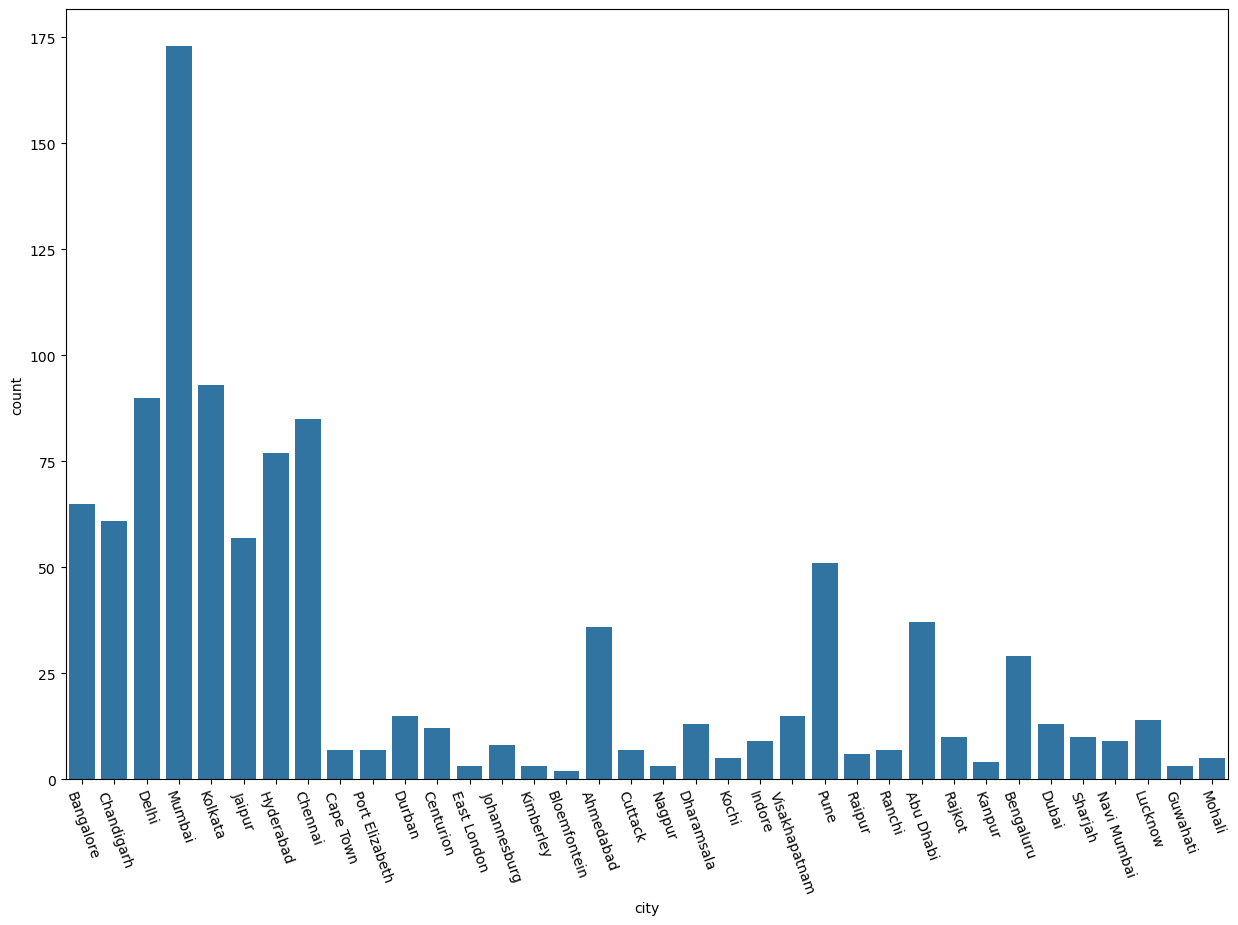

In [18]:
plt.figure(figsize = (15,10))
sns.countplot(data=matches, x = 'city')
plt.xticks(rotation=-70)
plt.show()

In [19]:
matches['city'].value_counts()

city
Mumbai            173
Kolkata            93
Delhi              90
Chennai            85
Hyderabad          77
Bangalore          65
Chandigarh         61
Jaipur             57
Pune               51
Abu Dhabi          37
Ahmedabad          36
Bengaluru          29
Durban             15
Visakhapatnam      15
Lucknow            14
Dubai              13
Dharamsala         13
Centurion          12
Rajkot             10
Sharjah            10
Indore              9
Navi Mumbai         9
Johannesburg        8
Cuttack             7
Port Elizabeth      7
Ranchi              7
Cape Town           7
Raipur              6
Mohali              5
Kochi               5
Kanpur              4
Kimberley           3
East London         3
Guwahati            3
Nagpur              3
Bloemfontein        2
Name: count, dtype: int64

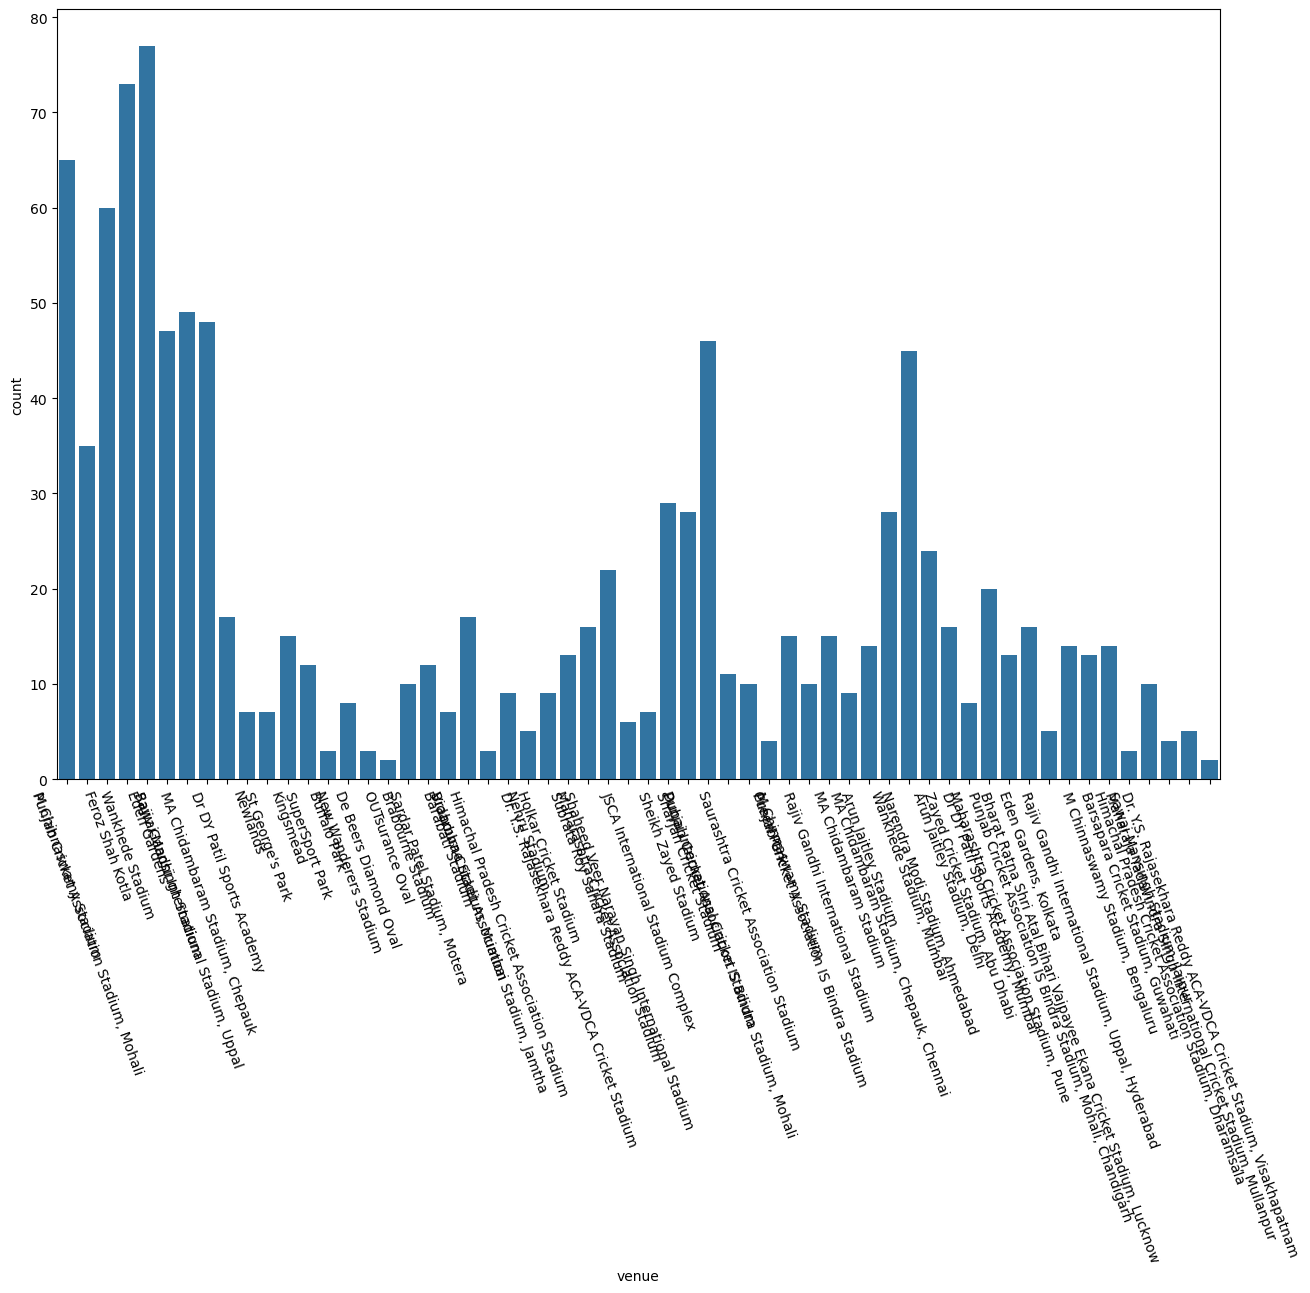

In [20]:
plt.figure(figsize = (15,10))
sns.countplot(data=matches, x = 'venue')
plt.xticks(rotation=-70)
plt.show()

In [21]:
matches['venue'].value_counts()

venue
Eden Gardens                                                             77
Wankhede Stadium                                                         73
M Chinnaswamy Stadium                                                    65
Feroz Shah Kotla                                                         60
Rajiv Gandhi International Stadium, Uppal                                49
MA Chidambaram Stadium, Chepauk                                          48
Sawai Mansingh Stadium                                                   47
Dubai International Cricket Stadium                                      46
Wankhede Stadium, Mumbai                                                 45
Punjab Cricket Association Stadium, Mohali                               35
Sheikh Zayed Stadium                                                     29
Sharjah Cricket Stadium                                                  28
MA Chidambaram Stadium, Chepauk, Chennai                                 28
Narend

In [22]:
result_count = matches['result'].value_counts()
result_count

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x2509c0a6660>,
 [Text(-0.09613339396061713, 1.0957912075599132, 'wickets'),
  Text(0.03628689157184371, -1.0994013195826415, 'runs'),
  Text(1.097393350313619, -0.07568245957585214, 'tie'),
  Text(1.0998868237743198, -0.015778938102376395, 'no result')],
 [Text(-0.05243639670579115, 0.5977042950326799, '52.8%'),
  Text(0.019792849948278384, -0.5996734470450771, '45.5%'),
  Text(0.5985781910801559, -0.04128134158682844, '1.3%'),
  Text(0.5999382675132653, -0.008606693510387124, '0.5%')])

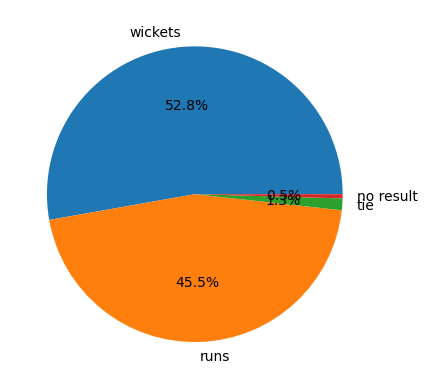

In [23]:
plt.pie(result_count,labels=result_count.index,autopct='%1.1f%%')

In [24]:
matches['player_of_match'].value_counts().head(10)

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
AD Russell        15
Name: count, dtype: int64

(array([  5.,   4.,   8.,   9.,  16.,  31.,  54.,  94., 134., 181., 170.,
        147., 107.,  64.,  35.,  20.,   5.,   3.,   3.,   2.]),
 array([ 43.  ,  55.25,  67.5 ,  79.75,  92.  , 104.25, 116.5 , 128.75,
        141.  , 153.25, 165.5 , 177.75, 190.  , 202.25, 214.5 , 226.75,
        239.  , 251.25, 263.5 , 275.75, 288.  ]),
 <BarContainer object of 20 artists>)

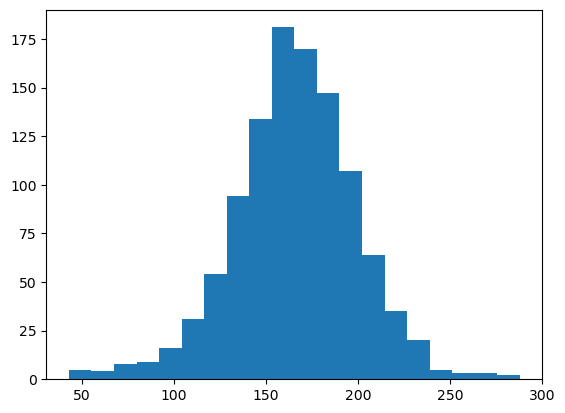

In [25]:
plt.hist(matches['target_runs'],bins = 20)

<Axes: xlabel='target_runs'>

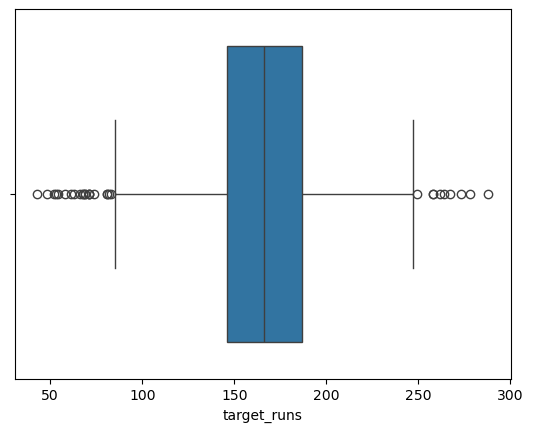

In [26]:
sns.boxplot(data = matches, x = 'target_runs')

## Multivariate/Bivariate Analysis